In [1]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json

pd.set_option('display.max_columns', None)

In [2]:
OPTIONS = json.loads(open('../../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'dynamic_tests': 1, 'static_tests': 1}

# IMPORTANDO DADOS

In [3]:
df_target = pd.read_csv('Target/output/data.csv')
df_target

,time,target_ay,target_roll,target_wx,target_pitch,target_wz,target_yaw,target_wy,target_ax,target_tmp,target_az
0,0.0,9.805483,1.425,0.08723,0.151,-0.37984,357.398,-0.01616,0.008365,56.0,0.230142
1,0.1,9.826734,1.425,-0.03215,0.150,-0.08479,357.398,0.38399,0.012641,56.1,0.268035
2,0.2,9.809925,1.424,-0.10574,0.150,-0.00581,357.399,0.11879,0.052387,56.0,0.278126
3,0.3,9.789341,1.424,0.29974,0.151,-0.01572,357.399,-0.09042,0.047278,56.0,0.225465
4,0.4,9.805228,1.427,-0.39951,0.151,-0.08634,357.399,0.43024,0.029204,56.1,0.234732
...,...,...,...,...,...,...,...,...,...,...,...
413994,41399.4,9.772846,1.415,-0.11754,0.141,-0.04712,274.238,0.19151,0.036226,61.1,0.239429
413995,41399.5,9.758450,1.417,0.06235,0.140,0.49627,274.239,-0.14773,0.008904,61.3,0.269124
413996,41399.6,9.804218,1.415,0.20572,0.141,0.17441,274.239,-0.17914,-0.021418,61.3,0.274341
413997,41399.7,9.808268,1.416,0.37387,0.141,-0.32080,274.239,0.18711,0.028479,61.3,0.237664


In [4]:
df_ref = pd.read_csv('Reference/output/data.csv')
df_ref

,time,ref_ay,ref_q3,ref_roll,ref_la_pos_mon_d,ref_q0,ref_wx,ref_pitch,ref_wz,ref_yaw,ref_q2,ref_wy,ref_ax,ref_q1,ref_az,ref_sample_time
0,0.0,-9.785,-0.06359,88.636571,0.011670,0.7127,0.003799,-0.686403,0.007420,-10.869009,-0.07043,0.004279,-0.02951,0.6951,-0.2317,805000000.0
1,0.1,-9.785,-0.06359,88.636571,0.011610,0.7127,-0.006102,-0.686403,0.015573,-10.869009,-0.07043,-0.002887,-0.02964,0.6951,-0.2318,905000000.0
2,0.2,-9.785,-0.06360,88.636571,0.011560,0.7127,0.009654,-0.686403,0.011035,-10.869009,-0.07043,0.000790,-0.02962,0.6951,-0.2318,5000000.0
3,0.3,-9.785,-0.06361,88.636571,0.011500,0.7127,0.001686,-0.685830,-0.003356,-10.869009,-0.07044,-0.014570,-0.02954,0.6951,-0.2317,105000000.0
4,0.4,-9.785,-0.06361,88.636571,0.011450,0.7126,0.005651,-0.685830,-0.008743,-10.869009,-0.07044,0.003143,-0.02959,0.6951,-0.2319,205000000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413994,41399.4,-9.787,-0.01931,88.636571,-0.001588,-0.7152,0.000811,-0.399753,0.004295,2.702069,-0.01398,0.005850,-0.02464,-0.6986,-0.2317,505000000.0
413995,41399.5,-9.787,-0.01931,88.636571,-0.001526,-0.7152,0.008594,-0.399523,-0.004258,2.702642,-0.01398,0.005747,-0.02457,-0.6986,-0.2317,605000000.0
413996,41399.6,-9.787,-0.01931,88.636571,-0.001464,-0.7152,0.000384,-0.399753,0.004178,2.703215,-0.01398,0.010600,-0.02456,-0.6986,-0.2316,705000000.0
413997,41399.7,-9.787,-0.01931,88.636571,-0.001401,-0.7152,-0.002646,-0.399753,0.008434,2.702642,-0.01398,-0.002668,-0.02454,-0.6986,-0.2317,805000000.0


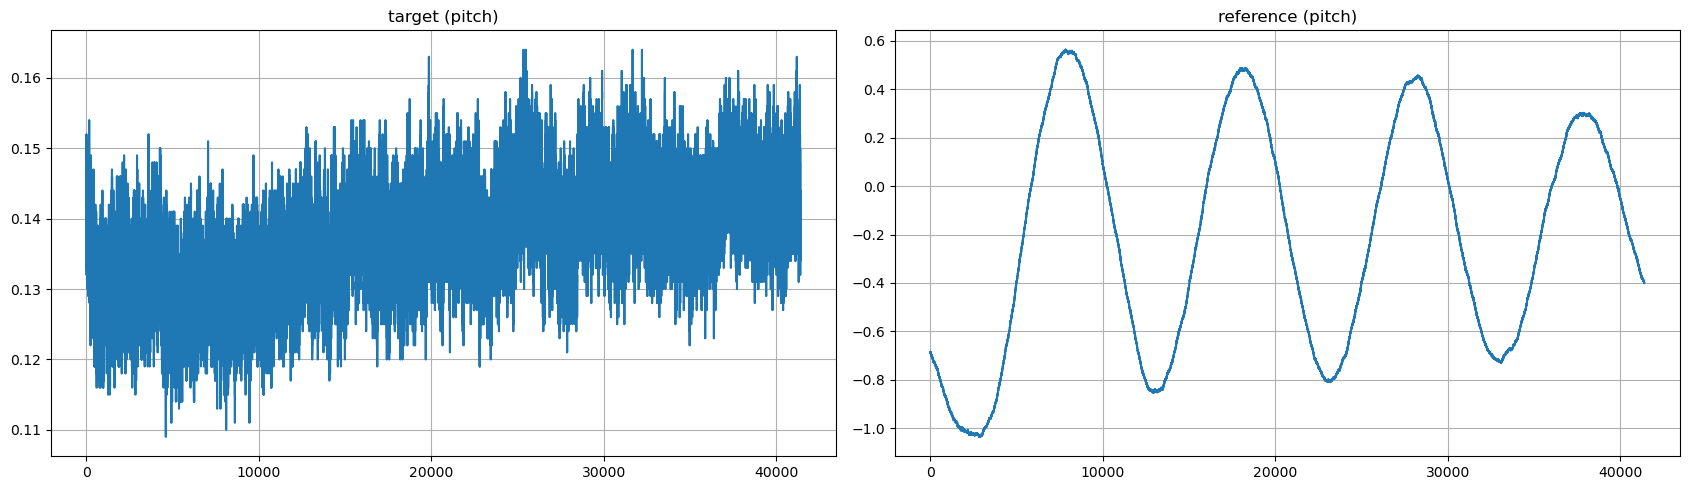

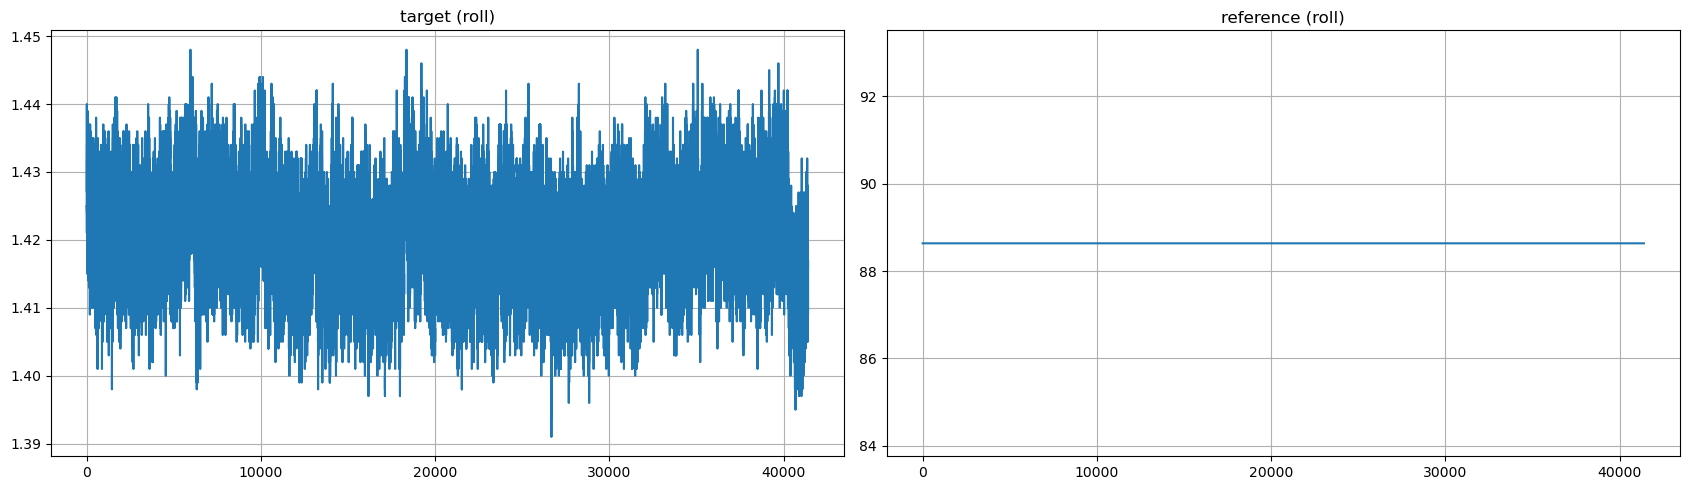

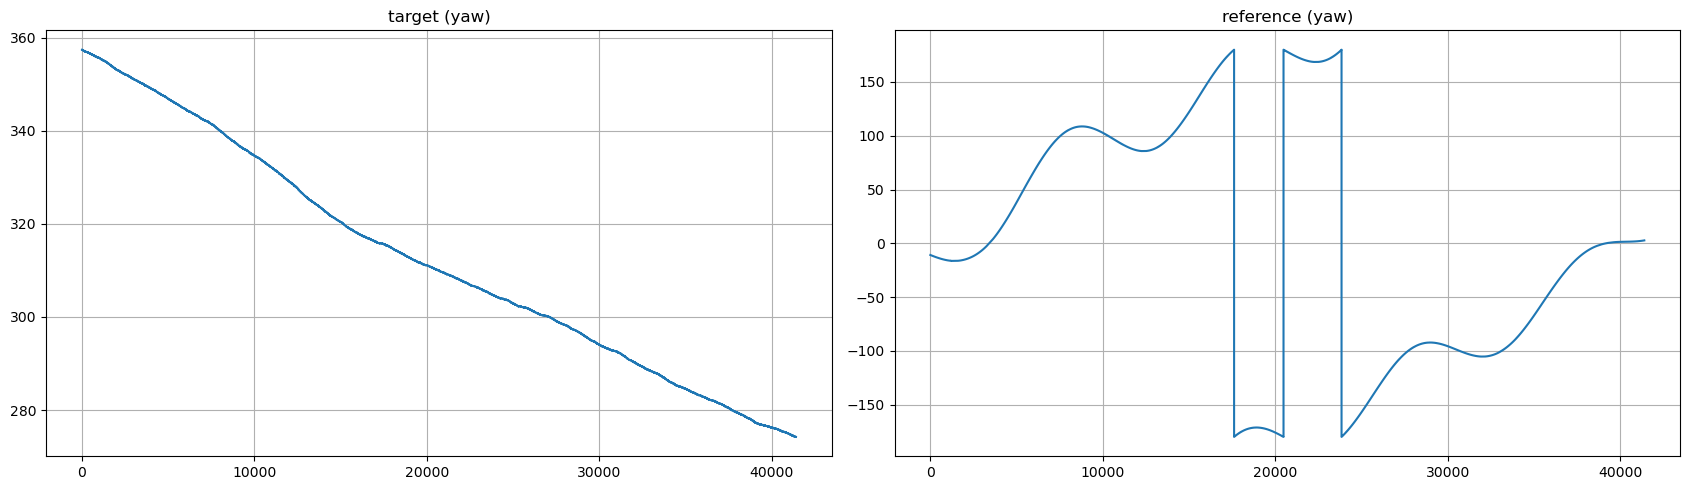

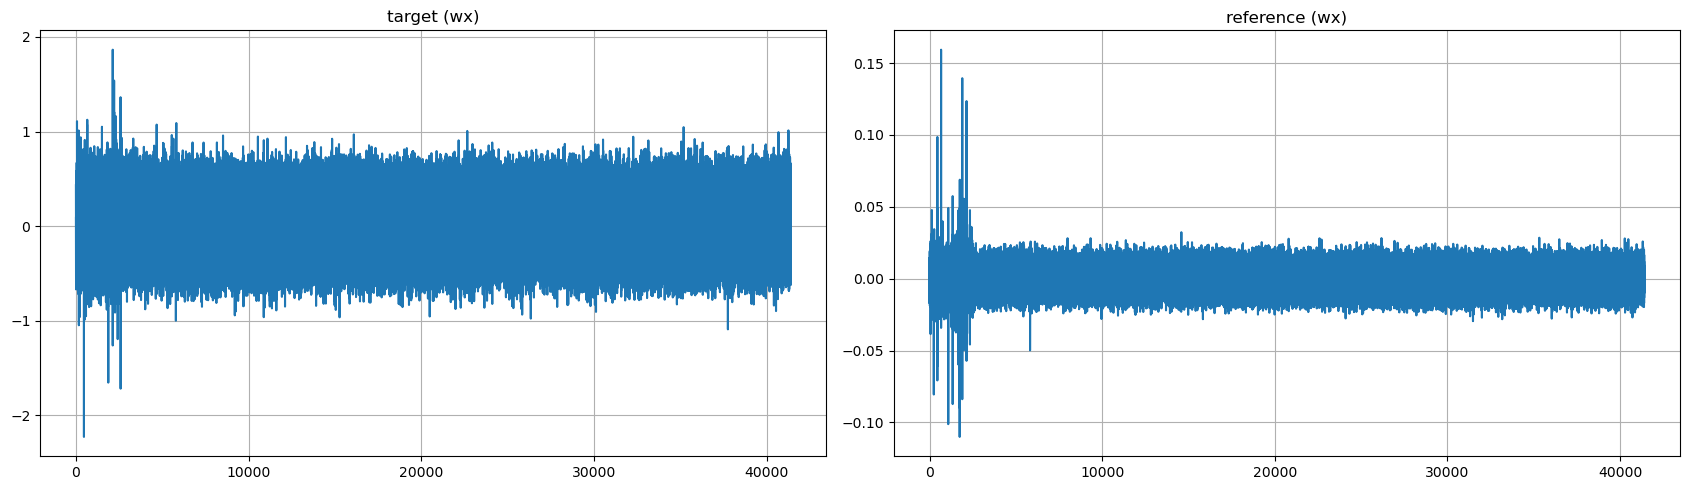

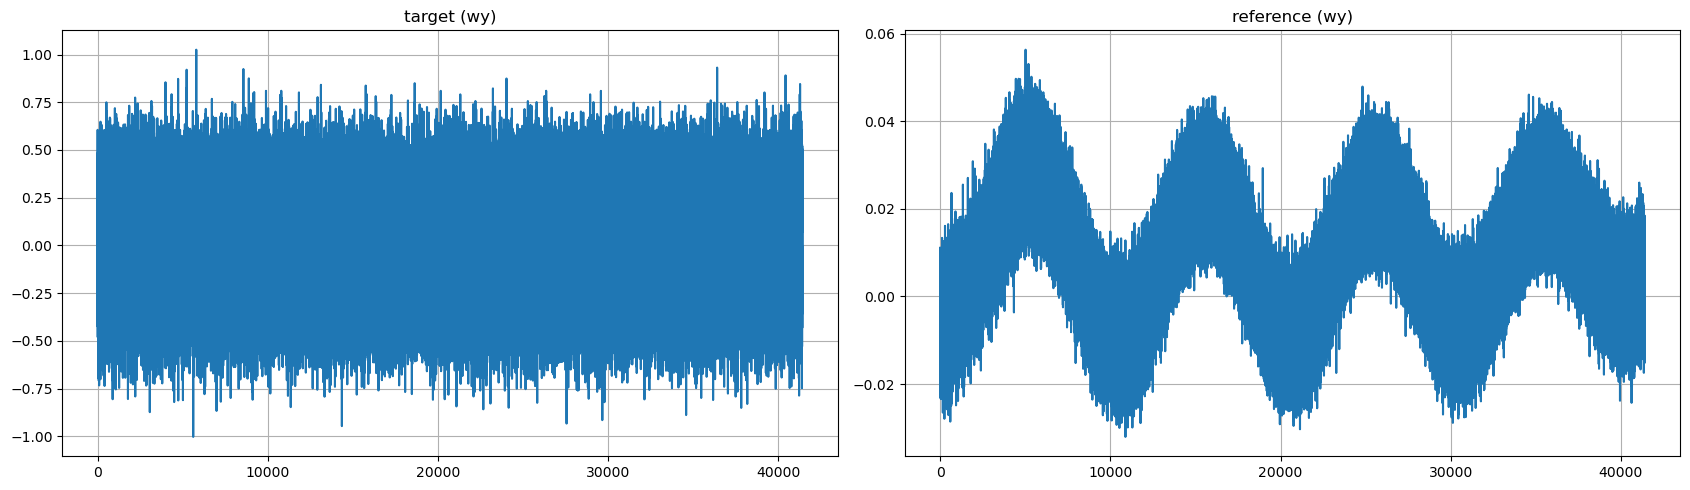

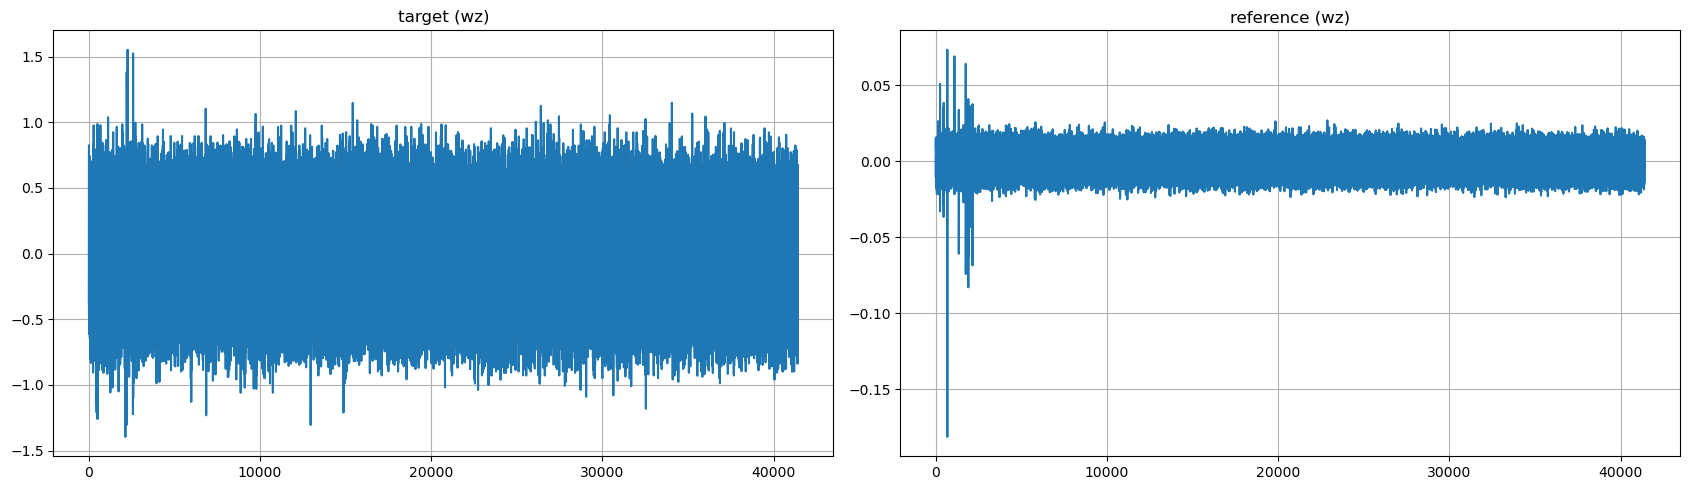

In [5]:
def compareAxis(data, time=None, figsize=None):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)   
    plt.figure(figsize=figsize if figsize is not None else (6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        time_data = time if time is not None else np.array(range(len(values)))
        
        plt.subplot(numRows, numCols, i+1)
        plt.plot(time_data, values)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()


for var in ['pitch', 'roll', 'yaw', 'wx', 'wy', 'wz']:
    compareAxis({
        f'target ({var})':    df_target[f'target_{var}'], 
        f'reference ({var})': df_ref[f'ref_{var}']
    }, time=df_ref.time, figsize=(17, 5))

In [6]:
df = pd.merge_asof(df_target, df_ref, on='time', direction='nearest')
df

,time,target_ay,target_roll,target_wx,target_pitch,target_wz,target_yaw,target_wy,target_ax,target_tmp,target_az,ref_ay,ref_q3,ref_roll,ref_la_pos_mon_d,ref_q0,ref_wx,ref_pitch,ref_wz,ref_yaw,ref_q2,ref_wy,ref_ax,ref_q1,ref_az,ref_sample_time
0,0.0,9.805483,1.425,0.08723,0.151,-0.37984,357.398,-0.01616,0.008365,56.0,0.230142,-9.785,-0.06359,88.636571,0.011670,0.7127,0.003799,-0.686403,0.007420,-10.869009,-0.07043,0.004279,-0.02951,0.6951,-0.2317,805000000.0
1,0.1,9.826734,1.425,-0.03215,0.150,-0.08479,357.398,0.38399,0.012641,56.1,0.268035,-9.785,-0.06359,88.636571,0.011610,0.7127,-0.006102,-0.686403,0.015573,-10.869009,-0.07043,-0.002887,-0.02964,0.6951,-0.2318,905000000.0
2,0.2,9.809925,1.424,-0.10574,0.150,-0.00581,357.399,0.11879,0.052387,56.0,0.278126,-9.785,-0.06360,88.636571,0.011560,0.7127,0.009654,-0.686403,0.011035,-10.869009,-0.07043,0.000790,-0.02962,0.6951,-0.2318,5000000.0
3,0.3,9.789341,1.424,0.29974,0.151,-0.01572,357.399,-0.09042,0.047278,56.0,0.225465,-9.785,-0.06361,88.636571,0.011500,0.7127,0.001686,-0.685830,-0.003356,-10.869009,-0.07044,-0.014570,-0.02954,0.6951,-0.2317,105000000.0
4,0.4,9.805228,1.427,-0.39951,0.151,-0.08634,357.399,0.43024,0.029204,56.1,0.234732,-9.785,-0.06361,88.636571,0.011450,0.7126,0.005651,-0.685830,-0.008743,-10.869009,-0.07044,0.003143,-0.02959,0.6951,-0.2319,205000000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413994,41399.4,9.772846,1.415,-0.11754,0.141,-0.04712,274.238,0.19151,0.036226,61.1,0.239429,-9.787,-0.01931,88.636571,-0.001588,-0.7152,0.000811,-0.399753,0.004295,2.702069,-0.01398,0.005850,-0.02464,-0.6986,-0.2317,505000000.0
413995,41399.5,9.758450,1.417,0.06235,0.140,0.49627,274.239,-0.14773,0.008904,61.3,0.269124,-9.787,-0.01931,88.636571,-0.001526,-0.7152,0.008594,-0.399523,-0.004258,2.702642,-0.01398,0.005747,-0.02457,-0.6986,-0.2317,605000000.0
413996,41399.6,9.804218,1.415,0.20572,0.141,0.17441,274.239,-0.17914,-0.021418,61.3,0.274341,-9.787,-0.01931,88.636571,-0.001464,-0.7152,0.000384,-0.399753,0.004178,2.703215,-0.01398,0.010600,-0.02456,-0.6986,-0.2316,705000000.0
413997,41399.7,9.808268,1.416,0.37387,0.141,-0.32080,274.239,0.18711,0.028479,61.3,0.237664,-9.787,-0.01931,88.636571,-0.001401,-0.7152,-0.002646,-0.399753,0.008434,2.702642,-0.01398,-0.002668,-0.02454,-0.6986,-0.2317,805000000.0


In [7]:
df.to_csv('output.csv', index=None)